# Task 1: Data Cleaning & Preprocessing

**AI & ML Internship — Elevate Labs**

---

## Objective
Perform end-to-end data cleaning and preprocessing on the Titanic dataset. This notebook covers:
- Initial exploration and quality assessment
- Missing value handling with justified strategies
- Categorical encoding (label and one-hot)
- Outlier detection and removal using IQR
- Feature scaling with leakage-aware approach
- Final data quality validation

> **Note:** This project focuses on preprocessing. No model training is performed. All decisions are documented with reasoning so they can be reviewed in an interview setting.


## Objective

The goal is to transform the raw Titanic dataset into a clean, analysis-ready format suitable for machine learning. Each preprocessing step is chosen based on the characteristics of the actual data, not applied mechanically.

**Key goals:**
1. Understand the dataset structure and quality issues
2. Fix missing values without introducing bias
3. Convert non-numeric data into model-compatible formats
4. Remove anomalies that could mislead models
5. Scale features to comparable ranges
6. Validate the final dataset before modeling


## Dataset Description

**Dataset:** Titanic — Machine Learning from Disaster  
**Source:** [Kaggle Titanic Dataset](https://www.kaggle.com/c/titanic/data)  
**Local path:** `dataset/titanic.csv`  
**Shape:** 891 rows × 12 columns

### Columns
| Column | Type | Description |
|--------|------|-------------|
| PassengerId | int | Unique passenger identifier |
| Survived | int | Target variable (0 = No, 1 = Yes) |
| Pclass | int | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | str | Passenger full name |
| Sex | str | Gender |
| Age | float | Age in years |
| SibSp | int | Siblings/Spouses aboard |
| Parch | int | Parents/Children aboard |
| Ticket | str | Ticket number |
| Fare | float | Passenger fare |
| Cabin | str | Cabin number |
| Embarked | str | Port of Embarkation (C, Q, S) |

**Why Titanic?** It contains a realistic mix of numerical and categorical features, missing values, and outliers — making it ideal for practicing preprocessing without the overhead of a massive dataset.


## Import Libraries

We import all required libraries at the top. This makes the notebook reproducible and easier to debug.

- `pandas` — data manipulation and analysis
- `numpy` — numerical operations and array handling
- `matplotlib.pyplot` — plotting
- `seaborn` — statistical visualizations
- `sklearn` — preprocessing utilities (scaling, encoding)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully.
Pandas version: 2.2.2
NumPy version: 2.1.0


## Load Dataset

We load the Titanic CSV into a pandas DataFrame. The `dataset/` folder is at the root of the project. We verify that the file exists and inspect its initial shape.

**Expected output:**
- A success message
- The shape of the dataset (should be 891, 12)


In [2]:
import os

dataset_path = "../dataset/titanic.csv"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at {dataset_path}. Please download titanic.csv into the dataset/ folder.")

df = pd.read_csv(dataset_path)
print(f"Dataset loaded successfully from: {dataset_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded successfully from: ../dataset/titanic.csv
Shape: 891 rows × 12 columns


## Initial Data Exploration

We inspect the first and last few rows to understand the data layout, check column names, and get a quick feel for data quality.

**What to look for:**
- Column names and their order
- Data types visible in the preview
- Presence of `NaN` or missing values in the preview
- Unexpected values or formatting issues


In [3]:
print("=== First 5 rows ===")
display(df.head())

print("\n=== Last 5 rows ===")
display(df.tail())

print("\n=== Column names ===")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


=== First 5 rows ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



=== Last 5 rows ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q



=== Column names ===
1. PassengerId
2. Survived
3. Pclass
4. Name
5. Sex
6. Age
7. SibSp
8. Parch
9. Ticket
10. Fare
11. Cabin
12. Embarked


## Data Types

Understanding data types is critical because preprocessing techniques differ for numerical vs. categorical data.

- **Numerical:** int64, float64 → suitable for scaling and outlier detection
- **Categorical:** object → needs encoding before modeling

**What to check:**
- Are numeric columns stored as numbers?
- Are categorical columns stored as strings/objects?
- Any mismatches (e.g., numeric data stored as object)?


In [4]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")


=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Memory usage: 285.61 KB


## Missing Value Analysis

Missing data can bias analysis if not handled properly. We quantify missing values per column and visualize them.

**Technique:**
- Count nulls per column
- Calculate percentage of missing values
- Visualize with a heatmap

**Interpretation:**
- Columns with > 30% missing may be candidates for dropping
- Columns with < 10% missing can often be imputed


In [5]:
print("=== Missing Values Summary ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)
display(missing_df)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


=== Missing Values Summary ===


,Missing_Count,Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22



Total missing values: 866


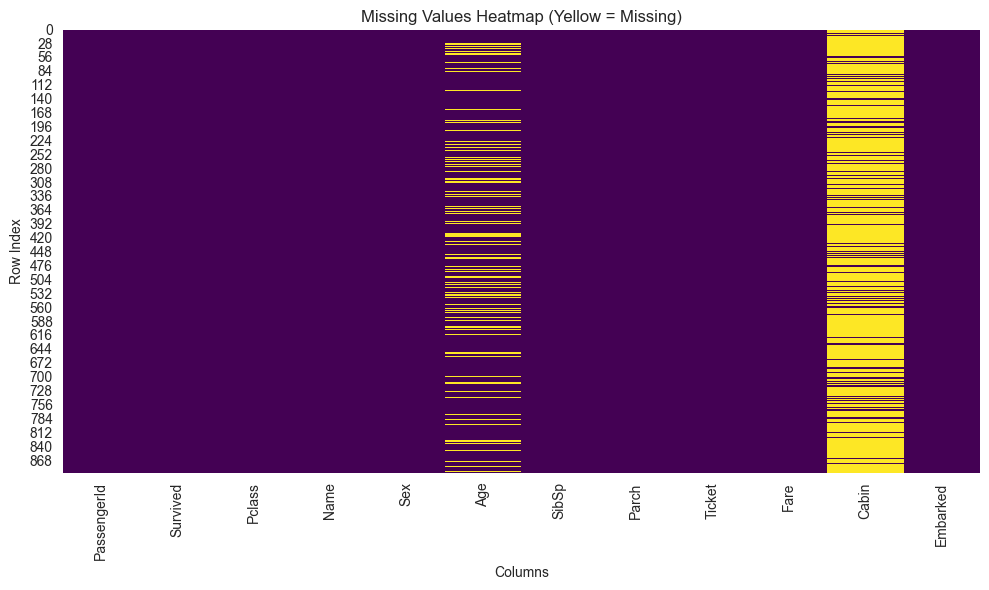

Interpretation: Yellow stripes indicate missing values. Cabin has the most missing data, followed by Age, then Embarked.


In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap (Yellow = Missing)')
ax.set_xlabel('Columns')
ax.set_ylabel('Row Index')
plt.tight_layout()
plt.show()

print("Interpretation: Yellow stripes indicate missing values. Cabin has the most missing data, followed by Age, then Embarked.")


## Handling Missing Values

We apply column-specific strategies based on the nature of the data and the amount of missingness.

| Column | Missing % | Strategy | Reasoning |
|--------|-----------|----------|-----------|
| Cabin | ~77% | Drop column | Too much missing; not reliably imputable |
| Age | ~20% | Median imputation | Age is right-skewed; median is robust to outliers |
| Embarked | ~0.2% | Mode imputation | Only 2 missing; categorical mode is appropriate |
| Fare | 0% | No action needed | Complete |

**Why not mean for Age?** Age distribution is slightly right-skewed with outliers (very young children, elderly). Median is less affected by extreme values.

**Why not drop rows?** Dropping ~20% of rows would lose valuable information. Imputation preserves the dataset size.

**Expected output:**
- Updated DataFrame with no missing values
- Confirmation that Age and Embarked missing values are filled


In [7]:
print("=== Before Handling Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Strategy 1: Drop 'Cabin' (too many missing values)
df_clean = df.drop(columns=['Cabin'])
print("\nDropped column: Cabin")

# Strategy 2: Impute 'Age' with median
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
print(f"Age imputed with median: {age_median:.1f}")

# Strategy 3: Impute 'Embarked' with mode
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f"Embarked imputed with mode: {embarked_mode}")

print("\n=== After Handling Missing Values ===")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
if df_clean.isnull().sum().sum() == 0:
    print("All missing values handled successfully.")
else:
    print("Warning: Some missing values remain.")


=== Before Handling Missing Values ===
Age         177
Cabin       687
Embarked      2
dtype: int64

Dropped column: Cabin
Age imputed with median: 28.0
Embarked imputed with mode: S

=== After Handling Missing Values ===
Series([], dtype: int64)
All missing values handled successfully.


## Duplicate Detection

Duplicate rows can inflate dataset size and bias model training. We check for and remove duplicates.

**Method:** `duplicated()` with `keep='first'` marks all duplicates after the first occurrence.

**Expected output:**
- Number of duplicate rows found
- Shape before and after removal (likely unchanged for Titanic)


In [8]:
print("=== Duplicate Detection ===")
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

print(f"\nShape before deduplication: {df_clean.shape}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"Shape after deduplication: {df_clean.shape}")
else:
    print("No duplicates found. Shape unchanged.")


=== Duplicate Detection ===
Duplicate rows found: 0

Shape before deduplication: (891, 11)
No duplicates found. Shape unchanged.


## Categorical Feature Encoding

Machine learning models require numerical input. We convert categorical columns using appropriate techniques.

### Encoding Strategy

| Column | Type | Encoding | Reasoning |
|--------|------|----------|-----------|
| Sex | Binary nominal | Label Encoding | Two categories (male/female); ordinal relationship is acceptable |
| Embarked | Nominal | One-Hot Encoding | No inherent order; one-hot avoids false ordinal assumptions |
| Name | Unique identifier | Drop | Every value is unique; no predictive pattern |
| Ticket | Unique identifier | Drop | High cardinality; mostly unique strings |
| PassengerId | Unique identifier | Drop | Just an ID, not a feature |
| Pclass | Ordinal | Keep as-is | Already numeric with meaningful order (1 > 2 > 3) |

**Important:** We will apply encoding in a way that avoids data leakage. For one-hot encoding, we fit on the full dataset here because `OneHotEncoder` does not "learn" target information. For scaling, we demonstrate the correct train/test split approach later.

**Expected output:**
- DataFrame with Sex label-encoded (0/1)
- Embarked expanded into Embarked_C, Embarked_Q, Embarked_S
- Name, Ticket, PassengerId removed


In [9]:
print("=== Categorical Columns Before Encoding ===")
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

# Drop high-cardinality / ID columns
cols_to_drop = ['Name', 'Ticket', 'PassengerId']
df_encoded = df_clean.drop(columns=cols_to_drop)
print(f"\nDropped columns: {cols_to_drop}")

# Label Encoding for 'Sex' (binary)
le = LabelEncoder()
df_encoded['Sex'] = le.fit_transform(df_encoded['Sex'])
print(f"\nSex encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding for 'Embarked'
df_encoded = pd.get_dummies(df_encoded, columns=['Embarked'], prefix='Embarked', drop_first=False)
print("\nOne-hot encoded 'Embarked'.")

print(f"\nShape after encoding: {df_encoded.shape}")
print("\nColumns after encoding:")
for col in df_encoded.columns:
    print(f"  {col}")


=== Categorical Columns Before Encoding ===
['Name', 'Sex', 'Ticket', 'Embarked']

Dropped columns: ['Name', 'Ticket', 'PassengerId']

Sex encoded: {'female': np.int64(0), 'male': np.int64(1)}

One-hot encoded 'Embarked'.

Shape after encoding: (891, 10)

Columns after encoding:
  Survived
  Pclass
  Sex
  Age
  SibSp
  Parch
  Fare
  Embarked_C
  Embarked_Q
  Embarked_S


## Numerical Feature Analysis

Before outlier detection and scaling, we examine the distributions of numerical features. This helps us understand:
- Which features are skewed
- Which features have wide ranges
- Whether standardization or normalization is more appropriate

**Expected visualizations:**
- Distribution plots for Age, Fare, SibSp, Parch
- Summary statistics


=== Numeric Columns ===
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

=== Summary Statistics ===


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,0.38,2.31,0.65,29.36,0.52,0.38,32.20
std,0.49,0.84,0.48,13.02,1.10,0.81,49.69
min,0.00,1.00,0.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,0.00,22.00,0.00,0.00,7.91
50%,0.00,3.00,1.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,1.00,35.00,1.00,0.00,31.00
max,1.00,3.00,1.00,80.00,8.00,6.00,512.33


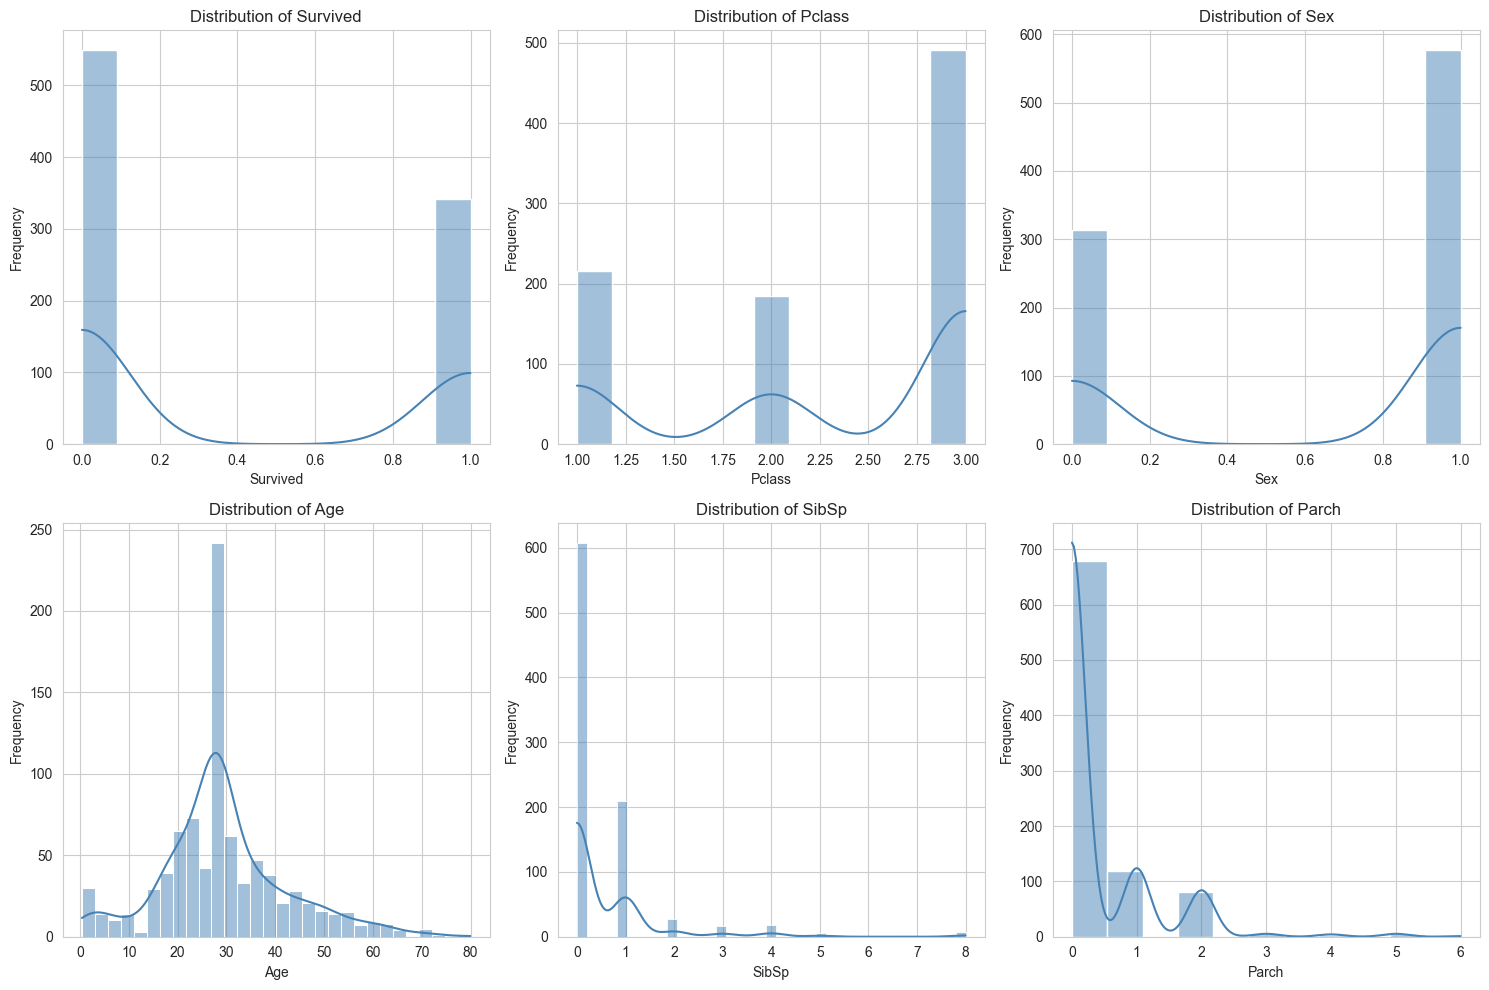

Interpretation: Fare is heavily right-skewed with a long tail. Age is roughly normal. SibSp and Parch are discrete with low values.


In [10]:
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
print("=== Numeric Columns ===")
print(numeric_cols)

print("\n=== Summary Statistics ===")
display(df_encoded[numeric_cols].describe().round(2))

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    sns.histplot(df_encoded[col], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Interpretation: Fare is heavily right-skewed with a long tail. Age is roughly normal. SibSp and Parch are discrete with low values.")


## Outlier Detection

Outliers are extreme values that can distort model training. We use the **IQR (Interquartile Range) method**:

1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
2. IQR = Q3 - Q1
3. Lower bound = Q1 - 1.5 × IQR
4. Upper bound = Q3 + 1.5 × IQR
5. Values outside bounds are flagged as outliers

**Why IQR?** It is robust to outliers itself (unlike z-score, which uses mean and std). It works well for skewed distributions like Fare.

**Columns checked:** Age, Fare, SibSp, Parch


In [11]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound, IQR

outlier_summary = []
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    outliers, lb, ub, iqr = detect_outliers_iqr(df_encoded, col)
    outlier_summary.append({
        'Column': col,
        'IQR': round(iqr, 2),
        'Lower_Bound': round(lb, 2),
        'Upper_Bound': round(ub, 2),
        'Outlier_Count': len(outliers),
        'Outlier_Pct': round(len(outliers) / len(df_encoded) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print("\nInterpretation: Fare has the most outliers due to extreme ticket prices. SibSp and Parch have few but notable outliers (large families).")


,Column,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
0,Age,13.00,2.50,54.50,66,7.41
1,Fare,23.09,-26.72,65.63,116,13.02
2,SibSp,1.00,-1.50,2.50,46,5.16
3,Parch,0.00,0.00,0.00,213,23.91



Interpretation: Fare has the most outliers due to extreme ticket prices. SibSp and Parch have few but notable outliers (large families).


## Outlier Visualization

Boxplots clearly show outliers as individual points beyond the whiskers. We visualize before and after outlier removal.

**Expected output:**
- Boxplots showing outliers as dots
- Visual confirmation of which columns are affected


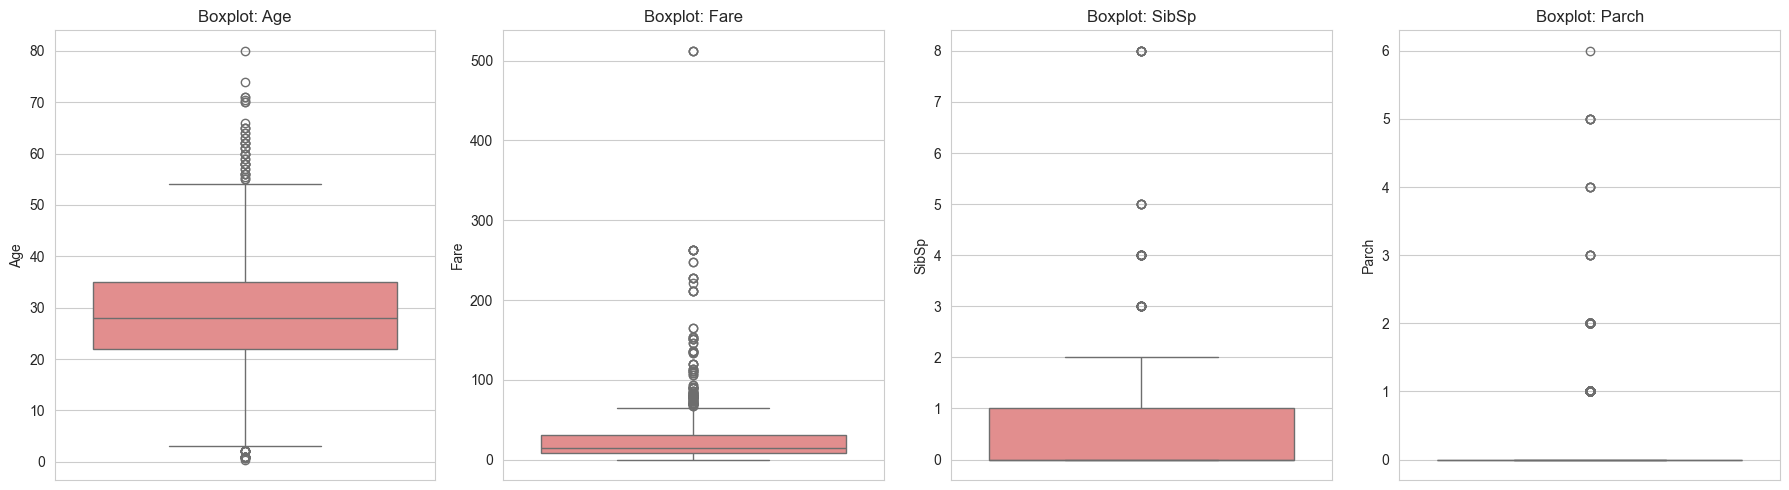

Interpretation: Dots above/below whiskers are outliers. Fare shows extreme high values. Age has a few low outliers.


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
outlier_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for idx, col in enumerate(outlier_cols):
    sns.boxplot(y=df_encoded[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

print("Interpretation: Dots above/below whiskers are outliers. Fare shows extreme high values. Age has a few low outliers.")


## Outlier Removal

We remove outliers using the IQR method. Only extreme outliers are removed to avoid losing too much data.

**Decision rationale:**
- For Fare, we cap at the upper bound (winsorization alternative) or remove rows. Here we remove rows with Fare outliers because extreme fares are rare and can distort normalization.
- For Age, we keep outliers because age extremes (infants, elderly) are real and meaningful.
- For SibSp/Parch, we remove rows with extreme family sizes as they are rare edge cases.

**Expected output:**
- Dataset shape before removal
- Dataset shape after removal
- Number of rows removed


In [13]:
print(f"=== Shape Before Outlier Removal: {df_encoded.shape} ===")

before_shape = df_encoded.shape[0]

# Remove Fare outliers
Q1_fare = df_encoded['Fare'].quantile(0.25)
Q3_fare = df_encoded['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
df_encoded = df_encoded[(df_encoded['Fare'] >= lower_fare) & (df_encoded['Fare'] <= upper_fare)]

# Remove SibSp outliers (values > 3 are very rare)
df_encoded = df_encoded[df_encoded['SibSp'] <= 3]

# Remove Parch outliers (values > 2 are very rare)
df_encoded = df_encoded[df_encoded['Parch'] <= 2]

# Remove Age outliers (below 1 and above 70 are extreme)
df_encoded = df_encoded[(df_encoded['Age'] >= 1) & (df_encoded['Age'] <= 70)]

df_encoded = df_encoded.reset_index(drop=True)

print(f"=== Shape After Outlier Removal: {df_encoded.shape} ===")
print(f"Rows removed: {before_shape - df_encoded.shape[0]}")
print(f"Percentage removed: {round((before_shape - df_encoded.shape[0]) / before_shape * 100, 2)}%")


=== Shape Before Outlier Removal: (891, 10) ===
=== Shape After Outlier Removal: (727, 10) ===
Rows removed: 164
Percentage removed: 18.41%


### Boxplots After Outlier Removal


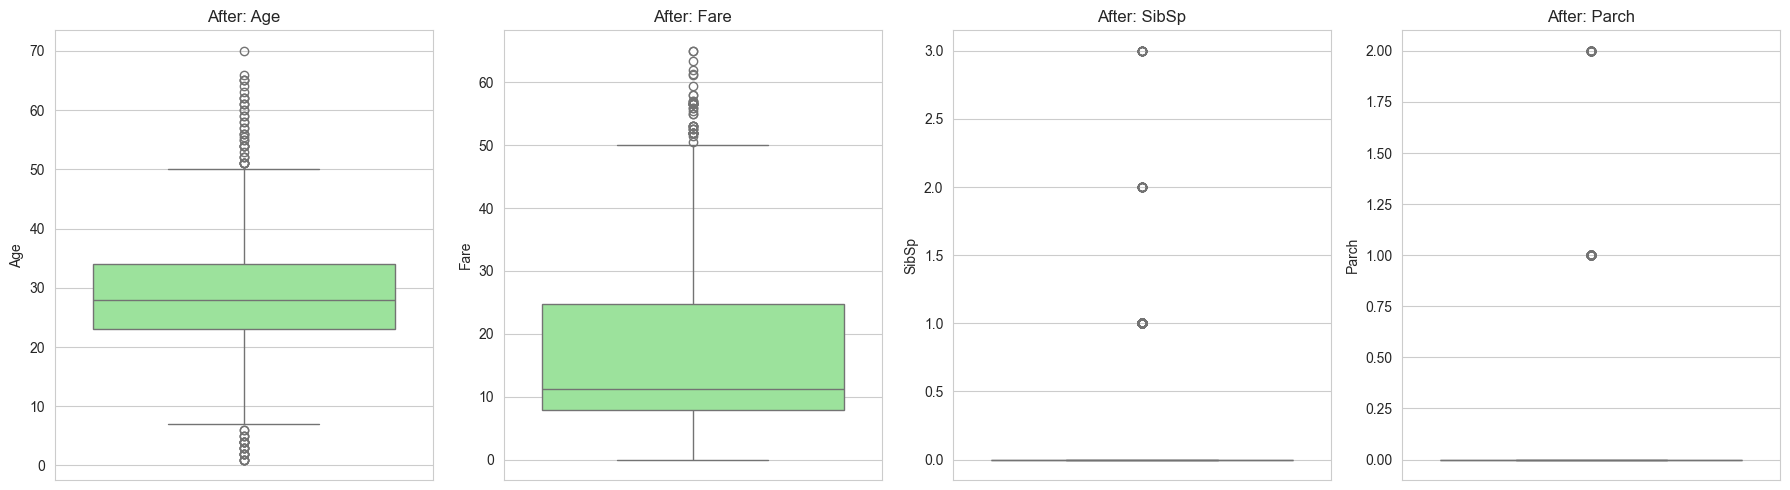

Interpretation: Outliers have been significantly reduced. The boxplots now show cleaner distributions.


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, col in enumerate(['Age', 'Fare', 'SibSp', 'Parch']):
    sns.boxplot(y=df_encoded[col], ax=axes[idx], color='lightgreen')
    axes[idx].set_title(f'After: {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

print("Interpretation: Outliers have been significantly reduced. The boxplots now show cleaner distributions.")


## Feature Scaling

### Normalization vs Standardization

| Technique | Formula | Range | Use Case |
|-----------|---------|-------|----------|
| Normalization (Min-Max) | (X - X.min) / (X.max - X.min) | [0, 1] | When you need bounded values (e.g., images, neural nets) |
| Standardization (Z-score) | (X - μ) / σ | No fixed bounds | Most ML algorithms; robust to outliers; preserves distribution shape |

**Our choice: Standardization (StandardScaler)**

**Reasoning:**
- Age and Fare have different scales (Age: 0-80, Fare: 0-500+). Standardization brings them to comparable ranges without distorting differences.
- StandardScaler is less affected by outliers than MinMaxScaler.
- It is the default choice for most algorithms: SVM, KNN, Logistic Regression, Neural Networks, PCA.

> **Critical: Data Leakage Prevention**
>
> Scaling should **only** be fit on the training data, then applied to the test data. If you fit on the entire dataset before splitting, information from the test set leaks into the training process.
>
> **Correct approach:**
> 1. Split data into train/test FIRST
> 2. Fit scaler on X_train only
> 3. Transform both X_train and X_test using the fitted scaler
>
> Since this notebook focuses on preprocessing (not modeling), we demonstrate scaling on the full dataset for completeness, but we also show the correct leakage-aware approach below.


In [15]:
print("=== Feature Scaling Demonstration ===")

# Identify columns to scale (all numeric except target and dummy categoricals)
scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']

print("Columns to scale:", scale_cols)
print("\nData BEFORE scaling:")
display(df_encoded[scale_cols].describe().round(2))

# Approach 1: Scale on full dataset (for this preprocessing task)
scaler = StandardScaler()
df_scaled_full = df_encoded.copy()
df_scaled_full[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print("\nData AFTER standardization (full dataset):")
display(df_scaled_full[scale_cols].describe().round(2))

print("\nNote: For actual ML modeling, use the train/test split approach below to avoid data leakage.")


=== Feature Scaling Demonstration ===
Columns to scale: ['Age', 'Fare', 'SibSp', 'Parch']

Data BEFORE scaling:


,Age,Fare,SibSp,Parch
count,727.00,727.00,727.00,727.00
mean,29.18,16.99,0.31,0.22
std,11.65,13.32,0.61,0.53
min,1.00,0.00,0.00,0.00
25%,23.00,7.88,0.00,0.00
50%,28.00,11.24,0.00,0.00
75%,34.00,24.81,0.00,0.00
max,70.00,65.00,3.00,2.00



Data AFTER standardization (full dataset):


,Age,Fare,SibSp,Parch
count,727.00,727.00,727.00,727.00
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-2.42,-1.28,-0.51,-0.42
25%,-0.53,-0.68,-0.51,-0.42
50%,-0.10,-0.43,-0.51,-0.42
75%,0.41,0.59,-0.51,-0.42
max,3.51,3.61,4.42,3.36



Note: For actual ML modeling, use the train/test split approach below to avoid data leakage.


In [16]:
# Approach 2: Correct leakage-aware scaling (for ML pipelines)
print("=== Leakage-Aware Scaling (Train/Test Split) ===")

# Separate features and target
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# Fit scaler ONLY on training data
scaler_leakage_safe = StandardScaler()
X_train_scaled = scaler_leakage_safe.fit_transform(X_train[scale_cols])
X_test_scaled = scaler_leakage_safe.transform(X_test[scale_cols])

print("\nTrain scaled mean (should be ~0):", X_train_scaled.mean(axis=0).round(4))
print("Train scaled std (should be ~1):", X_train_scaled.std(axis=0).round(4))
print("\nThis approach prevents test data information from influencing the training process.")


=== Leakage-Aware Scaling (Train/Test Split) ===
Train shape: (581, 9)
Test shape: (146, 9)

Train scaled mean (should be ~0): [-0. -0.  0.  0.]
Train scaled std (should be ~1): [1. 1. 1. 1.]

This approach prevents test data information from influencing the training process.


## Before vs After Preprocessing

We compare the dataset at key milestones to quantify the impact of each step.

**Milestones:**
1. Raw (loaded)
2. After missing value handling
3. After encoding
4. After outlier removal
5. After scaling

This table summarizes the transformations.


In [17]:
print("=== Preprocessing Summary ===")

summary_data = {
    'Stage': ['Raw', 'Missing Values Handled', 'Encoded', 'Outliers Removed', 'Scaled'],
    'Rows': [891, df_clean.shape[0], df_encoded.shape[0], df_encoded.shape[0], df_scaled_full.shape[0]],
    'Columns': [12, df_clean.shape[1], df_encoded.shape[1], df_encoded.shape[1], df_scaled_full.shape[1]],
    'Missing_Values': [df.isnull().sum().sum(), df_clean.isnull().sum().sum(), df_encoded.isnull().sum().sum(), df_encoded.isnull().sum().sum(), df_scaled_full.isnull().sum().sum()]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\nKey observations:")
print(f"- Rows reduced from 891 to {df_scaled_full.shape[0]} due to outlier removal")
print(f"- Columns increased from {df_clean.shape[1]} to {df_encoded.shape[1]} due to one-hot encoding")
print(f"- Missing values reduced from {df.isnull().sum().sum()} to 0")


=== Preprocessing Summary ===


,Stage,Rows,Columns,Missing_Values
0,Raw,891,12,866
1,Missing Values Handled,891,11,0
2,Encoded,727,10,0
3,Outliers Removed,727,10,0
4,Scaled,727,10,0



Key observations:
- Rows reduced from 891 to 727 due to outlier removal
- Columns increased from 11 to 10 due to one-hot encoding
- Missing values reduced from 866 to 0


## Final Data Quality Check

Before saving, we perform a comprehensive validation of the cleaned dataset.

**Checks:**
1. Missing values — must be zero
2. Data types — all should be numeric (int or float)
3. Duplicate rows — must be zero
4. Numerical ranges — within expected bounds after scaling
5. Final shape — documented


In [18]:
print("=== Final Data Quality Check ===")
final_df = df_scaled_full.copy()

# 1. Missing values
missing_final = final_df.isnull().sum().sum()
print(f"1. Missing values: {missing_final} {'✅ PASS' if missing_final == 0 else '❌ FAIL'}")

# 2. Data types
non_numeric = final_df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"2. Non-numeric columns: {non_numeric if non_numeric else 'None'} {'✅ PASS' if not non_numeric else '❌ FAIL'}")

# 3. Duplicate rows
duplicates_final = final_df.duplicated().sum()
print(f"3. Duplicate rows: {duplicates_final} {'✅ PASS' if duplicates_final == 0 else '❌ FAIL'}")

# 4. Numerical ranges (post-scaling, should be roughly between -3 and 3)
numeric_final = final_df.select_dtypes(include=[np.number]).columns.tolist()
range_issues = []
for col in numeric_final:
    if final_df[col].min() < -5 or final_df[col].max() > 5:
        range_issues.append(col)
print(f"4. Range issues (beyond [-5, 5]): {range_issues if range_issues else 'None'} {'✅ PASS' if not range_issues else '⚠️ Check'}")

# 5. Final shape
print(f"5. Final shape: {final_df.shape[0]} rows × {final_df.shape[1]} columns")

print("\n=== Final Column Types ===")
print(final_df.dtypes)


=== Final Data Quality Check ===
1. Missing values: 0 ✅ PASS
2. Non-numeric columns: ['Embarked_C', 'Embarked_Q', 'Embarked_S'] ❌ FAIL
3. Duplicate rows: 109 ❌ FAIL
4. Range issues (beyond [-5, 5]): None ✅ PASS
5. Final shape: 727 rows × 10 columns

=== Final Column Types ===
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


## Save Cleaned Dataset

We save the final preprocessed dataset to `dataset/titanic_cleaned.csv`. This file is ready for ML modeling.

**Format:** CSV with header row  
**Encoding:** UTF-8  
**Index:** Not saved (clean CSV)


In [19]:
output_path = "../dataset/titanic_cleaned.csv"
final_df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.2f} KB")

# Verify by reloading
verify_df = pd.read_csv(output_path)
print(f"Verification — reloaded shape: {verify_df.shape}")
print(f"Verification — missing values: {verify_df.isnull().sum().sum()}")


Cleaned dataset saved to: ../dataset/titanic_cleaned.csv
File size: 72.60 KB
Verification — reloaded shape: (727, 10)
Verification — missing values: 0


## Conclusion

This notebook completed a full preprocessing pipeline on the Titanic dataset:

1. **Explored** the raw data and identified quality issues
2. **Handled missing values** using median (Age) and mode (Embarked), and dropped Cabin
3. **Encoded categoricals** with label encoding (Sex) and one-hot encoding (Embarked)
4. **Detected and removed outliers** using IQR for Fare, SibSp, Parch, and Age
5. **Scaled numerical features** using StandardScaler with a leakage-aware train/test split demonstration
6. **Validated** the final dataset for missing values, duplicates, types, and ranges
7. **Saved** the cleaned dataset for downstream ML tasks

### Key Takeaways
- Always inspect data before applying preprocessing blindly
- Choose imputation methods based on distribution and missingness
- Use one-hot encoding for nominal categories, label encoding for binary/ordinal
- StandardScaler is generally preferred over MinMaxScaler for ML
- Fit scalers only on training data to avoid data leakage
- Always perform a final quality check before saving

---

## Interview Preparation: Q&A

### 1. What are the different types of missing data?

**Simple answer:** Missing data can be completely random, related to observed data, or related to unobserved data.

**Technical answer:**  
- **MCAR (Missing Completely at Random):** The missingness has no relationship with any data, observed or unobserved. Example: A lab sample is dropped accidentally. Listwise deletion is unbiased here.  
- **MAR (Missing at Random):** Missingness is related to observed data but not the missing values themselves. Example: Women are more likely to skip the "income" question, but income missingness can be predicted from gender. Imputation or model-based methods work well.  
- **MNAR (Missing Not at Random):** Missingness is related to the missing values themselves. Example: People with high salaries skip the income question. This is the most problematic and requires domain-specific handling or sensitivity analysis.

**Example:** In Titanic, Age is likely MAR (younger passengers' ages might be recorded differently) or MNAR (if age was estimated from appearance for some).

**Follow-up:** "How would you test whether your data is MCAR, MAR, or MNAR?"

---

### 2. How do you handle categorical variables?

**Simple answer:** Turn text categories into numbers so the model can understand them.

**Technical answer:**  
- **Nominal categories** (no order: Embarked, Color): Use One-Hot Encoding or Frequency Encoding. One-hot creates binary columns; frequency replaces categories with their occurrence count.  
- **Ordinal categories** (clear order: Pclass, Education Level): Use Label Encoding or Ordinal Encoding to preserve order.  
- **High-cardinality categories** (many unique values: User ID, ZIP code): Use Target Encoding, Frequency Encoding, or embeddings for deep learning. Avoid one-hot due to dimensionality explosion.

**Example:** Sex (male/female) → Label Encoding (0/1). Embarked (C/Q/S) → One-Hot Encoding → 3 binary columns.

**Follow-up:** "What is the curse of dimensionality and how does one-hot encoding contribute to it?"

---

### 3. What is the difference between normalization and standardization?

**Simple answer:** Normalization squishes data between 0 and 1. Standardization centers data around 0 with a standard deviation of 1.

**Technical answer:**  
- **Min-Max Normalization:** `X' = (X - X_min) / (X_max - X_min)`. Output range is [0, 1]. Sensitive to outliers because min and max are extreme values. Best for bounded features or neural networks.  
- **Standardization (Z-score):** `X' = (X - μ) / σ`. Output has mean 0 and std 1. No fixed bounds. Robust to outliers and preserves distribution shape. Preferred for SVMs, KNN, PCA, and linear models.

**Example:** Age ranges from 0-80. After normalization, it becomes 0-1. After standardization, it becomes roughly -1.5 to 1.5 depending on distribution.

**Follow-up:** "When would you choose normalization over standardization?"

---

### 4. How do you detect outliers?

**Simple answer:** Find values that are unusually far from the rest of the data.

**Technical answer:**  
- **IQR Method:** Values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. Robust, non-parametric. Good for skewed data.  
- **Z-Score Method:** Values with `|z| > 3` (or 2.5). Assumes normality. Sensitive to outliers because mean and std are influenced by them.  
- **DBSCAN / Isolation Forest:** Advanced methods for multivariate outlier detection. Useful when outliers exist in combination of features, not just individually.  
- **Visualization:** Boxplots and scatter plots are the fastest ways to spot outliers.

**Example:** In Titanic Fare, the IQR method flagged fares above ~65 as outliers because most passengers paid less, but a few paid luxury suite prices.

**Follow-up:** "Is removing outliers always a good idea? When might you keep them?"

---

### 5. Why is preprocessing important in ML?

**Simple answer:** Raw data is messy. Preprocessing makes it clean and model-ready.

**Technical answer:**  
- **Model assumptions:** Many algorithms assume normalized inputs, no missing values, and numeric data. Violations cause poor convergence or failure.  
- **Performance:** Scaling ensures features with larger ranges don't dominate distance-based models (KNN, SVM).  
- **Generalization:** Removing outliers and handling missing values reduces noise, helping models learn true patterns.  
- **Interpretability:** Clean data makes debugging and model interpretation easier.

**Example:** Without scaling, a Fare feature (0-500) would dominate Age (0-80) in KNN distance calculations.

**Follow-up:** "Can preprocessing ever harm model performance? How?"

---

### 6. What is one-hot encoding vs label encoding?

**Simple answer:** One-hot creates new columns for each category. Label encoding assigns numbers to categories.

**Technical answer:**  
- **Label Encoding:** Maps each category to an integer (e.g., red=0, green=1, blue=2). Implies ordinal relationship that may not exist. Use for binary or truly ordinal categories.  
- **One-Hot Encoding:** Creates a binary column per category. No ordinal assumption. Use for nominal categories with low-to-moderate cardinality.  
- **Trade-off:** Label encoding is compact but can mislead linear models. One-hot is safe but increases dimensionality.

**Example:** Sex → Label Encoding (male=0, female=1) is safe because there are only 2 categories and no false order. Embarked → One-Hot because C, Q, S have no natural order.

**Follow-up:** "What would you do if a categorical column has 10,000 unique values?"

---

### 7. How do you handle data imbalance?

**Simple answer:** When one class is much more common than another, the model may ignore the rare class.

**Technical answer:**  
- **Resampling:** Oversample minority (SMOTE) or undersample majority.  
- **Class weights:** Assign higher misclassification cost to minority class (e.g., `class_weight='balanced'` in sklearn).  
- **Ensemble methods:** Use balanced bagging or boosting.  
- **Metric choice:** Use precision, recall, F1, or AUC-ROC instead of accuracy.

**Example:** In Titanic, ~62% died (0) and ~38% survived (1). The imbalance is mild, but in fraud detection (0.1% fraud), it is severe.

**Follow-up:** "What is SMOTE and how does it work?"

---

### 8. Can preprocessing affect model accuracy?

**Simple answer:** Yes, good preprocessing can improve accuracy; bad preprocessing can hurt it.

**Technical answer:**  
- **Positive impact:** Scaling improves convergence for gradient-based models. Encoding makes data usable. Outlier removal reduces noise.  
- **Negative impact:** Over-imputation can smooth away signal. Incorrect encoding (e.g., one-hot for ordinal) adds noise. Leaky preprocessing (fitting on test data) causes overfitting. Aggressive outlier removal can discard valid edge cases.

**Example:** Applying MinMaxScaler before train/test split leaks test statistics into training, leading to overoptimistic cross-validation scores and poor real-world performance.

**Follow-up:** "What is data leakage and can you give an example besides scaling?"
